# Exercise 5.01

we're doing trapezoid method over this list of velocity values in order to get distance values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## first

Let's look at what this graph looks like.

In [1]:
df = pd.read_csv('../data/velocities.txt', sep='\t', names=['t', 'v'])

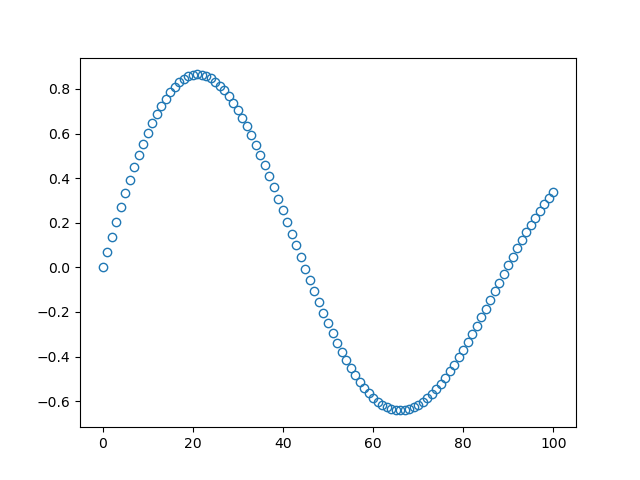

In [2]:
fig, ax =  plt.subplots()
ax.plot(df['t'], df['v'], 'o', mfc='none')

## next let's do the integral of the entire thing.

In [27]:
dt = 1

t = df['t']
v = df['v']

s = dt/2*(v[0]+v[100])
s = s + np.sum(v[1:100]*dt)

s

8.218923999999998

let's try my trapezoid method stored in scripts

In [28]:
import ph390 as ph

ph.trap(t, v)

7.8291534653465344

huh i wonder why that is so bad... hmmm

now i'll try my super special integral function

In [29]:
ph.integrate(t, v)

8.22269

# ok that was boring

Let's try a plot of the integral OVER time, like as time goes by. The answer at the end should be close to that value above.

The way we are going to do this is that we are going to integrate many times, one integral for each time of the graph, and then we will keep all of those values and plot them as time goes by.

In [31]:
v_list = []

for i in x:
    s = 0 # i'm repeating the full integral each time
    s = y[0]*dx/2
    s = s + np.sum(y[1:i]*dx)
    v_list.append(s)

keep in mind that in the above method, we are adding the first data point `s = y[0]*dx/2`, but we are not adding the last data point at `y[-1]*dx/2`. it is hard to handle special cases like this with a for loop, however, we could possibly know this and make a correction. this is a little farther afield than i want for this problem however.

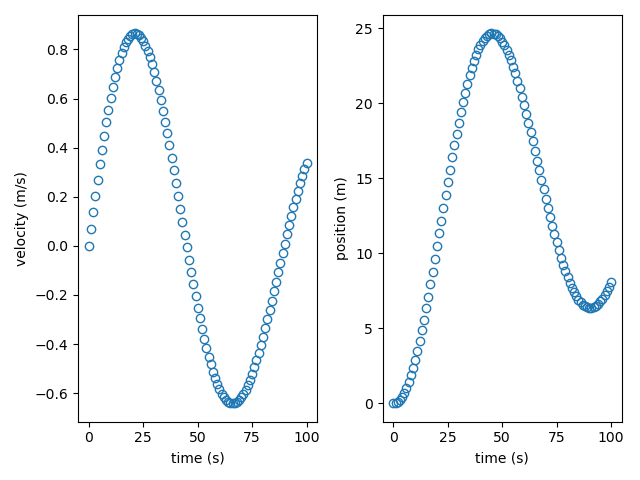

In [32]:
fig1, (ax1, ax2) = plt.subplots(1,2)

ax1.plot(df['t'], df['v'], 'o', mfc='none')
ax1.set_ylabel('velocity (m/s)')
ax1.set_xlabel('time (s)')
ax2.plot(df['t'], v_list, 'o', mfc='none')
ax2.set_ylabel('position (m)')
ax2.set_xlabel('time (s)')
fig1.tight_layout()

# so that last value is

In [33]:
v_list[-1]

8.050269999999998

which is not terribly far off from the integral that we got from the beginning. In the method we have employed to plot this, we have not added in the last value, so it makes sense that it is slightly off.

## let's try scipy integration

to see if that is better

In [18]:
import scipy as sc

In [19]:
sc.integrate.simpson(y, x)

8.222689999999998

In [20]:
yint = sc.integrate.cumulative_simpson(y,x=x,initial=0)

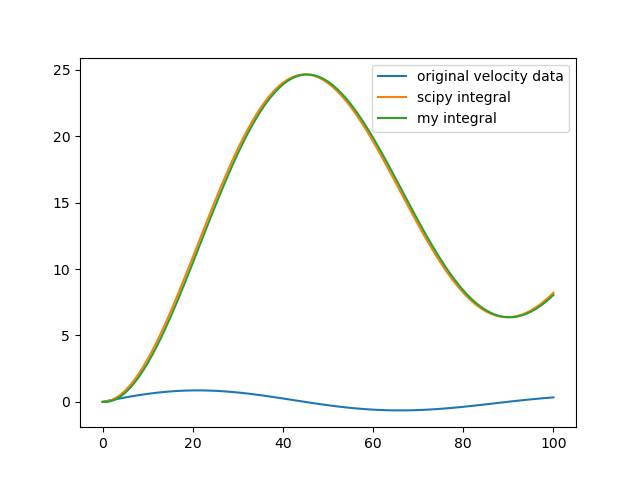

In [22]:
fig, ax = plt.subplots()
ax.plot(x, y, label='original velocity data')
ax.plot(x, yint, label='scipy integral')
ax.plot(x, v_list, label='my integral')
ax.legend()

it looks like my routine may be off from the beginning rather than the end... hmmmm.